<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 12.3</h1>

In this final exercise, we test the ability of the Convolutional Neural Network developed in Exercise 12.2 to recognize handwritten digits that were not part of the MNIST dataset. Since Exercises 12.2 and 12.3 are implemented in separate notebooks, the trained CNN model obtained in Exercise 12.2 is first saved and then loaded in this exercise, without performing any additional training. Ten handwritten digits are created using the `gimp` application and saved in the `Pictures` folder. The images are then imported into the Jupyter notebook and preprocessed in the same way as the MNIST images before being given as input to the previously trained CNN. The predicted labels are finally compared with the actual digits to evaluate how well the model generalizes to independently created handwritten images.

In [16]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import os

import pandas as pd

In [2]:
model_CNN = keras.models.load_model("CNN_MNIST.keras")

E0000 00:00:1787577496.077159 1599360 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         4,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,988 (121.05 KB)

 Trainable params: 30,986 (121.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [14]:
def load_digit(digit_filename):
    digit_in = Image.open(digit_filename).convert('L')

    ydim, xdim = digit_in.size

    pix = digit_in.load()
    data = np.zeros((xdim, ydim))

    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]

    data /= 255

    # Add batch and channel dimensions for the CNN
    data = data.reshape(1, xdim, ydim, 1)

    return data

In [15]:
results = []

for digit in range(10):

    filename = f"./Pictures/digit_{digit}.png"

    data = load_digit(filename)

    prediction = model_CNN.predict(data, verbose=0)

    predicted_digit = np.argmax(prediction)
    confidence = prediction[0, predicted_digit]

    results.append([
        digit,
        predicted_digit,
        confidence
    ])

In [17]:
results_df = pd.DataFrame(
    results,
    columns=["True digit", "Predicted digit", "Confidence"]
)

results_df

,True digit,Predicted digit,Confidence
0,0,0,0.999666
1,1,1,0.752549
2,2,2,0.999730
3,3,3,0.999929
4,4,4,0.852309
5,5,5,0.999742
6,6,5,0.812739
7,7,7,0.955747
8,8,3,0.643681
9,9,9,0.616573


In [18]:
accuracy_handwritten = np.mean(
    results_df["True digit"] == results_df["Predicted digit"]
)

print("Handwritten digit accuracy:", accuracy_handwritten)
print("Handwritten digit accuracy:", accuracy_handwritten * 100, "%")

Handwritten digit accuracy: 0.8
Handwritten digit accuracy: 80.0 %


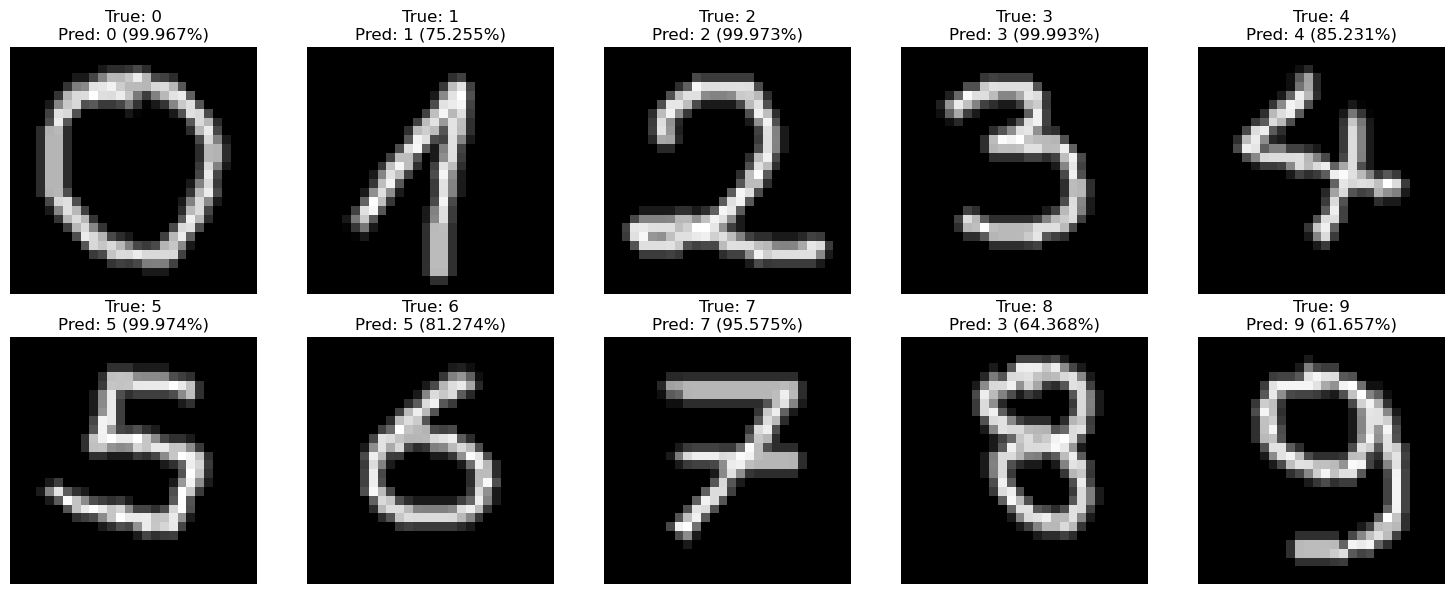

In [20]:
plt.figure(figsize=(15, 6))

for digit in range(10):

    filename = f"./Pictures/digit_{digit}.png"

    data = load_digit(filename)

    prediction = model_CNN.predict(data, verbose=0)
    predicted_digit = np.argmax(prediction)
    confidence = prediction[0, predicted_digit]

    ax = plt.subplot(2, 5, digit + 1)

    plt.imshow(data[0, :, :, 0], cmap="gray")

    plt.title(
        f"True: {digit}\n"
        f"Pred: {predicted_digit} ({confidence:.3%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

**Figure 1.** The ten handwritten digits from $0$ to $9$ are shown together with their true label, predicted label, and the corresponding prediction confidence. The CNN correctly recognizes $8$ out of the $10$ handwritten digits, with particularly high confidence for most of the correctly classified samples. The two misclassified digits are $6$ and $8$, which are predicted as $5$ and $3$, respectively. Despite these two errors, the results show that the model trained exclusively on the MNIST dataset is able to generalize well to independently generated handwritten digits.

**Misclassification of digit 6.** The handwritten digit $6$ is incorrectly classified as $5$, with a prediction confidence of approximately $81.27\%$. This relatively high confidence indicates that the particular shape of the handwritten digit shares features with the patterns associated with the digit $5$ in the training data. The error is therefore likely related to the specific way in which the digit was written rather than to a general inability of the network to recognize the digit $6$.

**Misclassification of digit 8.** The handwritten digit $8$ is incorrectly classified as $3$, with a confidence of approximately $64.37\%$. The lower confidence compared with the previous misclassification indicates greater uncertainty in the prediction. This error can be explained by the particular shape of the handwritten $8$, which may have presented features similar to those learned by the network for the digit $3$.